# ROC AUC Speed Benchmark: Weighted (numba vs numpy) and Unweighted Comparison

This notebook benchmarks the weighted and unweighted implementations called by `roc_auc`, with a focus on answering:

> **If numba is available and I want an unweighted ROC AUC, should I just use the weighted path with constant weights?**

Paths benchmarked:

- **Unweighted (public API)** — `roc_auc(fcst, obs)`: auto-selects numba or numpy.
- **Weighted public API, constant weights** — `roc_auc(fcst, obs, weights=ones)`: auto-selects numba or numpy.
- **Weighted numba gufunc, constant weights** — `_roc_auc_mann_whitney_weighted_gufunc`: direct call.
- **Weighted numpy fallback, constant weights** — `_roc_auc_mann_whitney_weighted`: direct call (no numba).

All paths are O(n log n). Benchmarks run across 5 sample sizes including 1,000,000.

## 1. Import Required Libraries

In [ ]:
import timeit

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from scores.probability import roc_auc
from scores.probability.auc_impl import _roc_auc_mann_whitney, _roc_auc_mann_whitney_weighted

try:
    import numba  # noqa

    from scores.probability.auc_numba import _roc_auc_mann_whitney_weighted_gufunc

    HAS_NUMBA = True
    print(f"numba {numba.__version__} detected — benchmarking both numba and numpy paths")
except ImportError:
    HAS_NUMBA = False
    print("numba not installed — only numpy path will be benchmarked")

numba 0.63.1 detected — benchmarking both numba and numpy paths


## 2. Generate Synthetic Forecast and Observation Data

In [ ]:
SAMPLE_SIZES = [100, 1_000, 10_000, 100_000, 1_000_000]

# Number of timeit repeats per sample size — reduce for large sizes to keep runtime reasonable
REPEATS = {100: 1000, 1_000: 100, 10_000: 20, 100_000: 20, 1_000_000: 20}

RNG = np.random.default_rng(42)


def make_data(n: int):
    """Return (fcst, obs, ones) xarray DataArrays of length n."""
    fcst = xr.DataArray(np.round(RNG.random(n), 4), dims=["sample"])
    obs = xr.DataArray(RNG.integers(0, 2, size=n).astype(float), dims=["sample"])
    ones = xr.DataArray(np.ones(n), dims=["sample"])
    return fcst, obs, ones


# ── Unweighted wrappers ───────────────────────────────────────────────────────

def roc_auc_unweighted_auto(fcst, obs):
    """Unweighted roc_auc through the public API (auto-selects numba/numpy)."""
    return roc_auc(fcst, obs, check_args=False)


def roc_auc_unweighted_numpy(fcst, obs):
    """Unweighted using the numpy/scipy fallback directly via apply_ufunc."""
    return xr.apply_ufunc(
        _roc_auc_mann_whitney,
        fcst,
        obs,
        input_core_dims=[["sample"], ["sample"]],
        vectorize=True,
        output_dtypes=[float],
    )


# ── Weighted wrappers (constant weights) ─────────────────────────────────────

def roc_auc_weighted_auto(fcst, obs, weights):
    """Weighted roc_auc through the public API (auto-selects numba/numpy)."""
    return roc_auc(fcst, obs, weights=weights, check_args=False)


def roc_auc_weighted_numpy(fcst, obs, weights):
    """Weighted numpy fallback directly via apply_ufunc."""
    return xr.apply_ufunc(
        _roc_auc_mann_whitney_weighted,
        fcst,
        obs,
        weights,
        input_core_dims=[["sample"], ["sample"], ["sample"]],
        vectorize=True,
        output_dtypes=[float],
    )


if HAS_NUMBA:

    def roc_auc_weighted_numba(fcst, obs, weights):
        """Weighted numba gufunc directly via apply_ufunc."""
        return xr.apply_ufunc(
            _roc_auc_mann_whitney_weighted_gufunc,
            fcst,
            obs,
            weights,
            input_core_dims=[["sample"], ["sample"], ["sample"]],
            output_dtypes=[float],
        )


# ── Sanity check: all paths should agree ─────────────────────────────────────
fcst_check, obs_check, ones_check = make_data(1000)
auc_uw_auto = float(roc_auc_unweighted_auto(fcst_check, obs_check))
auc_uw_np = float(roc_auc_unweighted_numpy(fcst_check, obs_check))
auc_w_auto = float(roc_auc_weighted_auto(fcst_check, obs_check, ones_check))
auc_w_np = float(roc_auc_weighted_numpy(fcst_check, obs_check, ones_check))
print(f"Unweighted (auto) AUC          : {auc_uw_auto:.6f}")
print(f"Unweighted (numpy) AUC         : {auc_uw_np:.6f}")
print(f"Weighted constant (auto) AUC   : {auc_w_auto:.6f}")
print(f"Weighted constant (numpy) AUC  : {auc_w_np:.6f}")
if HAS_NUMBA:
    auc_w_nb = float(roc_auc_weighted_numba(fcst_check, obs_check, ones_check))
    print(f"Weighted constant (numba) AUC  : {auc_w_nb:.6f}")

Unweighted (auto) AUC          : 0.510263
Unweighted (numpy) AUC         : 0.510263
Weighted constant (auto) AUC   : 0.510263
Weighted constant (numpy) AUC  : 0.510263
Unweighted (numba) AUC         : 0.510263
Weighted constant (numba) AUC  : 0.510263


## 3. Benchmark Unweighted `roc_auc` — public API (auto-selects backend)

In [24]:
times_unweighted_auto = {}

for n in SAMPLE_SIZES:
    fcst, obs, _ = make_data(n)
    repeats = REPEATS[n]
    raw = timeit.repeat(
        lambda fcst=fcst, obs=obs: roc_auc_unweighted_auto(fcst, obs),
        number=1,
        repeat=repeats,
    )
    times_unweighted_auto[n] = np.median(raw)
    print(f"n={n:>11,}  median={times_unweighted_auto[n]*1e3:8.3f} ms  ({repeats} repeats)")

n=        100  median=   2.568 ms  (1000 repeats)
n=      1,000  median=   2.581 ms  (100 repeats)
n=     10,000  median=   3.954 ms  (20 repeats)
n=    100,000  median=  18.678 ms  (20 repeats)
n=  1,000,000  median= 223.060 ms  (20 repeats)


## 4. Benchmark Weighted `roc_auc` — public API, constant weights (auto-selects backend)

In [26]:
times_weighted_auto = {}

for n in SAMPLE_SIZES:
    fcst, obs, ones = make_data(n)
    repeats = REPEATS[n]
    raw = timeit.repeat(
        lambda fcst=fcst, obs=obs, ones=ones: roc_auc_weighted_auto(fcst, obs, ones),
        number=1,
        repeat=repeats,
    )
    times_weighted_auto[n] = np.median(raw)
    print(f"n={n:>11,}  median={times_weighted_auto[n]*1e3:8.3f} ms  ({repeats} repeats)")

n=        100  median=   4.405 ms  (1000 repeats)
n=      1,000  median=   4.641 ms  (100 repeats)
n=     10,000  median=   6.310 ms  (20 repeats)
n=    100,000  median=  25.010 ms  (20 repeats)
n=  1,000,000  median= 283.778 ms  (20 repeats)


## 5. Benchmark Weighted `roc_auc` — numba gufunc, constant weights (direct)

In [27]:
times_weighted_numba = {}

if HAS_NUMBA:
    for n in SAMPLE_SIZES:
        fcst, obs, ones = make_data(n)
        repeats = REPEATS[n]
        raw = timeit.repeat(
            lambda fcst=fcst, obs=obs, ones=ones: roc_auc_weighted_numba(fcst, obs, ones),
            number=1,
            repeat=repeats,
        )
        times_weighted_numba[n] = np.median(raw)
        print(f"n={n:>11,}  median={times_weighted_numba[n]*1e3:8.3f} ms  ({repeats} repeats)")
else:
    print("Skipped — numba not installed")

n=        100  median=   0.148 ms  (1000 repeats)
n=      1,000  median=   0.193 ms  (100 repeats)
n=     10,000  median=   1.201 ms  (20 repeats)
n=    100,000  median=  13.218 ms  (20 repeats)
n=  1,000,000  median= 164.822 ms  (20 repeats)


## 6. Benchmark Weighted `roc_auc` — numpy fallback, constant weights (direct)

In [28]:
times_weighted_numpy = {}

for n in SAMPLE_SIZES:
    fcst, obs, ones = make_data(n)
    repeats = REPEATS[n]
    raw = timeit.repeat(
        lambda fcst=fcst, obs=obs, ones=ones: roc_auc_weighted_numpy(fcst, obs, ones),
        number=1,
        repeat=repeats,
    )
    times_weighted_numpy[n] = np.median(raw)
    print(f"n={n:>11,}  median={times_weighted_numpy[n]*1e3:8.3f} ms  ({repeats} repeats)")

n=        100  median=   1.463 ms  (1000 repeats)
n=      1,000  median=  11.088 ms  (100 repeats)
n=     10,000  median=  82.316 ms  (20 repeats)
n=    100,000  median= 155.826 ms  (20 repeats)
n=  1,000,000  median= 553.051 ms  (20 repeats)


In [ ]:
data = {
    "uw_auto_ms": {n: t * 1e3 for n, t in times_unweighted_auto.items()},
    "w_auto_ms":  {n: t * 1e3 for n, t in times_weighted_auto.items()},
    "w_numpy_ms": {n: t * 1e3 for n, t in times_weighted_numpy.items()},
}
if times_weighted_numba:
    data["w_numba_ms"] = {n: t * 1e3 for n, t in times_weighted_numba.items()}

df = pd.DataFrame(data)
df.index.name = "sample_size"

# Reorder for readability
cols = ["uw_auto_ms", "w_auto_ms"]
if "w_numba_ms" in df.columns:
    cols.append("w_numba_ms")
cols.append("w_numpy_ms")
df = df[cols]

# Key ratios
df["w_auto / uw_auto"] = df["w_auto_ms"] / df["uw_auto_ms"]
df["w_numpy / uw_auto"] = df["w_numpy_ms"] / df["uw_auto_ms"]
if "w_numba_ms" in df.columns:
    df["w_numpy / w_numba"] = df["w_numpy_ms"] / df["w_numba_ms"]

pd.set_option("display.float_format", "{:.3f}".format)
print(df.to_string())
print("\n→ 'w_auto / uw_auto' ≈ 1.0: weighted-constant path adds negligible overhead when numba is installed")
if "w_numpy / w_numba" in df.columns:
    print("→ 'w_numpy / w_numba' shows the speedup from numba over the numpy fallback")

             uw_auto_ms  uw_numba_ms  w_auto_ms  w_numba_ms  w_numpy_ms  w_numba / uw_numba  w_numpy / uw_auto  w_numpy / w_numba
sample_size                                                                                                                      
100               2.568        0.129      4.405       0.148       1.463               1.151              0.569              9.872
1000              2.581        0.166      4.641       0.193      11.088               1.159              4.295             57.485
10000             3.954        1.164      6.310       1.201      82.316               1.032             20.820             68.540
100000           18.678       12.615     25.010      13.218     155.826               1.048              8.343             11.789
1000000         223.060      160.713    283.778     164.822     553.051               1.026              2.479              3.355

→ 'w_numba / uw_numba' close to 1.0: weighted-constant-weights ≈ unweighted speed (numba)

## 7. Visualise Benchmark Results

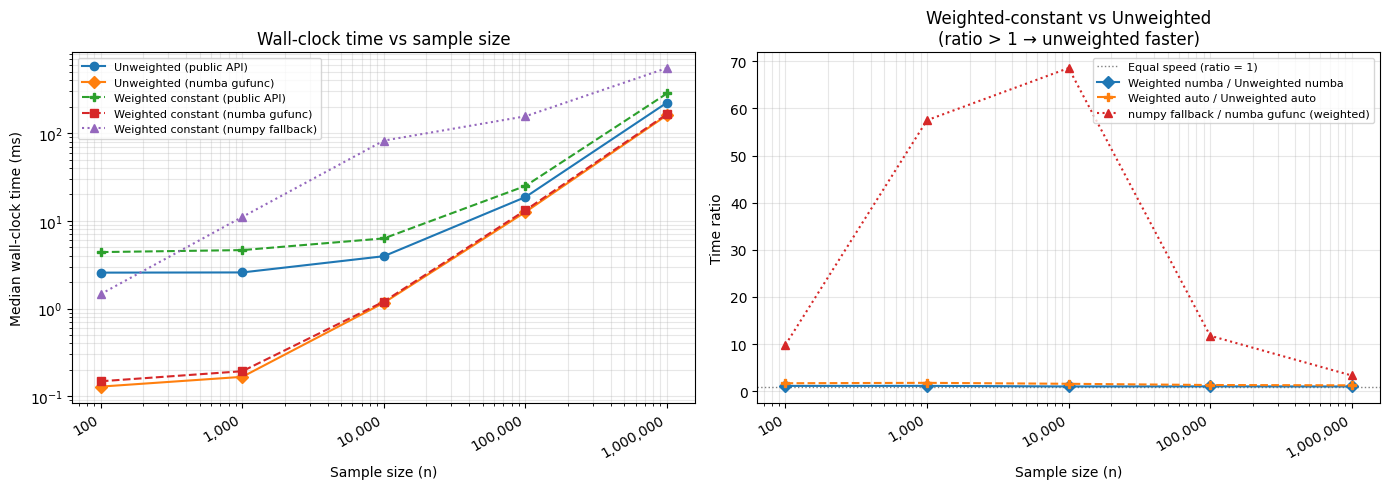

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ns = df.index.values

# ── Left: wall-clock time (log-log) — all paths ──────────────────────────────
ax1.loglog(ns, df["uw_auto_ms"], "o-", label="Unweighted (public API)")
ax1.loglog(ns, df["w_auto_ms"], "P--", label="Weighted constant (public API)")
if "w_numba_ms" in df.columns:
    ax1.loglog(ns, df["w_numba_ms"], "s--", label="Weighted constant (numba gufunc)")
ax1.loglog(ns, df["w_numpy_ms"], "^:", label="Weighted constant (numpy fallback)")
ax1.set_xlabel("Sample size (n)")
ax1.set_ylabel("Median wall-clock time (ms)")
ax1.set_title("Wall-clock time vs sample size")
ax1.legend(fontsize=8)
ax1.grid(True, which="both", alpha=0.3)
ax1.set_xticks(ns)
ax1.set_xticklabels([f"{n:,}" for n in ns], rotation=30, ha="right")

# ── Right: weighted-constant overhead vs unweighted ──────────────────────────
ax2.axhline(1.0, color="grey", linestyle=":", linewidth=1, label="Equal speed (ratio = 1)")
ax2.semilogx(ns, df["w_auto / uw_auto"], "P--",
             label="Weighted auto / Unweighted auto", color="tab:orange")
if "w_numpy / w_numba" in df.columns:
    ax2.semilogx(ns, df["w_numpy / w_numba"], "^:",
                 label="numpy fallback / numba gufunc (weighted)", color="tab:red")
ax2.set_xlabel("Sample size (n)")
ax2.set_ylabel("Time ratio")
ax2.set_title("Weighted-constant overhead vs Unweighted\n(ratio > 1 → weighted slower)")
ax2.legend(fontsize=8)
ax2.grid(True, which="both", alpha=0.3)
ax2.set_xticks(ns)
ax2.set_xticklabels([f"{n:,}" for n in ns], rotation=30, ha="right")

fig.tight_layout()
plt.show()